## Introduction to Probability and Statistics
## Assignment

In this assignment, we will use the dataset of diabetes patients taken [from here](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html).

In [6]:
!wget https://raw.githubusercontent.com/XW-ABAP/Data-Science-For-Beginners/main/data/diabetes.tsv -P sample_data/

--2026-10-08 05:33:39--  https://raw.githubusercontent.com/XW-ABAP/Data-Science-For-Beginners/main/data/diabetes.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18496 (18K) [text/plain]
Saving to: ‘sample_data/diabetes.tsv’

diabetes.tsv        100%[===================>]  18.06K  --.-KB/s    in 0.005s  

2026-10-08 05:33:39 (3.83 MB/s) - ‘sample_data/diabetes.tsv’ saved [18496/18496]



In [11]:
import os
import requests

# 1. 定义根目录下的文件列表
root_files = [
    "SOCR_MLB.tsv",
    "UID_ISO_FIPS_LookUp_Table.csv",
    "birds.csv",
    "diabetes.tsv",
    "emails.csv",
    "form.csv",
    "honey.csv",
    "mushrooms.csv",
    "taxi.csv",
]

# 2. 定义 COVID 文件夹下的文件列表
covid_files = [
    "time_series_covid19_confirmed_global.csv",
    "time_series_covid19_deaths_global.csv",
    "time_series_covid19_recovered_global.csv",
]

# 确保目标基础目录存在
base_dir = "sample_data"
covid_target_dir = os.path.join(base_dir, "COVID")
os.makedirs(covid_target_dir, exist_ok=True)

# 基础 URL
github_base = (
    "https://raw.githubusercontent.com/XW-ABAP/Data-Science-For-Beginners/main/data/"
)

# 下载根目录文件到 sample_data/
print("--- 开始下载根目录文件 ---")
for file in root_files:
  url = github_base + file
  response = requests.get(url)
  if response.status_code == 200:
    file_path = os.path.join(base_dir, file)
    with open(file_path, "wb") as f:
      f.write(response.content)
    print(f"成功: {file}")
  else:
    print(f"失败 ({response.status_code}): {file}")

# 下载 COVID 文件夹文件到 sample_data/COVID/
print("\n--- 开始下载 COVID 文件夹文件 ---")
for file in covid_files:
  url = github_base + "COVID/" + file
  response = requests.get(url)
  if response.status_code == 200:
    file_path = os.path.join(covid_target_dir, file)
    with open(file_path, "wb") as f:
      f.write(response.content)
    print(f"成功: COVID/{file}")
  else:
    print(f"失败 ({response.status_code}): COVID/{file}")

print("\n所有文件同步完成！")

--- 开始下载根目录文件 ---
成功: SOCR_MLB.tsv
成功: UID_ISO_FIPS_LookUp_Table.csv
成功: birds.csv
成功: diabetes.tsv
成功: emails.csv
成功: form.csv
成功: honey.csv
成功: mushrooms.csv
成功: taxi.csv

--- 开始下载 COVID 文件夹文件 ---
成功: COVID/time_series_covid19_confirmed_global.csv
成功: COVID/time_series_covid19_deaths_global.csv
成功: COVID/time_series_covid19_recovered_global.csv

所有文件同步完成！


In [12]:
import os

# 1. 打印当前的工作目录路径
print("当前工作目录:", os.getcwd())

# 2. 列出该目录下的所有文件和文件夹
print("目录下的文件:", os.listdir('.'))

当前工作目录: /content
目录下的文件: ['.config', 'sample_data']


In [13]:
import os

# 1. 打印当前的工作目录路径
print("当前工作目录:", os.getcwd())

# 2. 列出 sample_data 目录下的所有文件和文件夹
print("sample_data 目录下的文件:", os.listdir('sample_data'))

当前工作目录: /content
sample_data 目录下的文件: ['README.md', 'anscombe.json', 'SOCR_MLB.tsv', 'mushrooms.csv', 'diabetes.tsv', 'birds.csv', 'form.csv', 'taxi.csv', 'honey.csv', 'UID_ISO_FIPS_LookUp_Table.csv', 'emails.csv', 'COVID', 'california_housing_train.csv', 'mnist_test.csv', 'california_housing_test.csv', 'mnist_train_small.csv']


In [14]:
import pandas as pd
import numpy as np

# 从 sample_data 目录读取 diabetes.tsv 文件
df = pd.read_csv("sample_data/diabetes.tsv", sep='\t')
df.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



In this dataset, columns as the following:
* Age and sex are self-explanatory
* BMI is body mass index
* BP is average blood pressure
* S1 through S6 are different blood measurements
* Y is the qualitative measure of disease progression over one year

Let's study this dataset using methods of probability and statistics.

### Task 1: Compute mean values and variance for all values

In [17]:
import pandas as pd
import numpy as np

# 从 sample_data 目录读取 diabetes.tsv 文件[cite: 1]
df = pd.read_csv("sample_data/diabetes.tsv", sep='\t')

# 1. 计算所有数值列的均值 (Mean)
mean_values = df.mean()
print("=== 各列均值 (Mean) ===")
print(mean_values)

print("\n" + "="*30 + "\n")

# 2. 计算所有数值列的方差 (Variance)
# 注：pandas 的 var() 默认计算的是样本方差（自由度 ddof=1）
var_values = df.var()
print("=== 各列方差 (Variance) ===")
print(var_values)

# 提示：如果你想一步到位查看包括均值、标准差、最大最小值等综合统计量，也可以直接使用：
# print(df.describe())

=== 各列均值 (Mean) ===
AGE     48.518100
SEX      1.468326
BMI     26.375792
BP      94.647014
S1     189.140271
S2     115.439140
S3      49.788462
S4       4.070249
S5       4.641411
S6      91.260181
Y      152.133484
dtype: float64


=== 各列方差 (Variance) ===
AGE     171.846610
SEX       0.249561
BMI      19.519798
BP      191.304401
S1     1197.717241
S2      924.955494
S3      167.293585
S4        1.665261
S5        0.272892
S6      132.165712
Y      5943.331348
dtype: float64


### Task 2: Plot boxplots for BMI, BP and Y depending on gender

/tmp/ipykernel_1435/4194567894.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEX', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_1435/4194567894.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEX', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_1435/4194567894.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEX', y=col, data=df, ax=axes[i], palette='Set2')


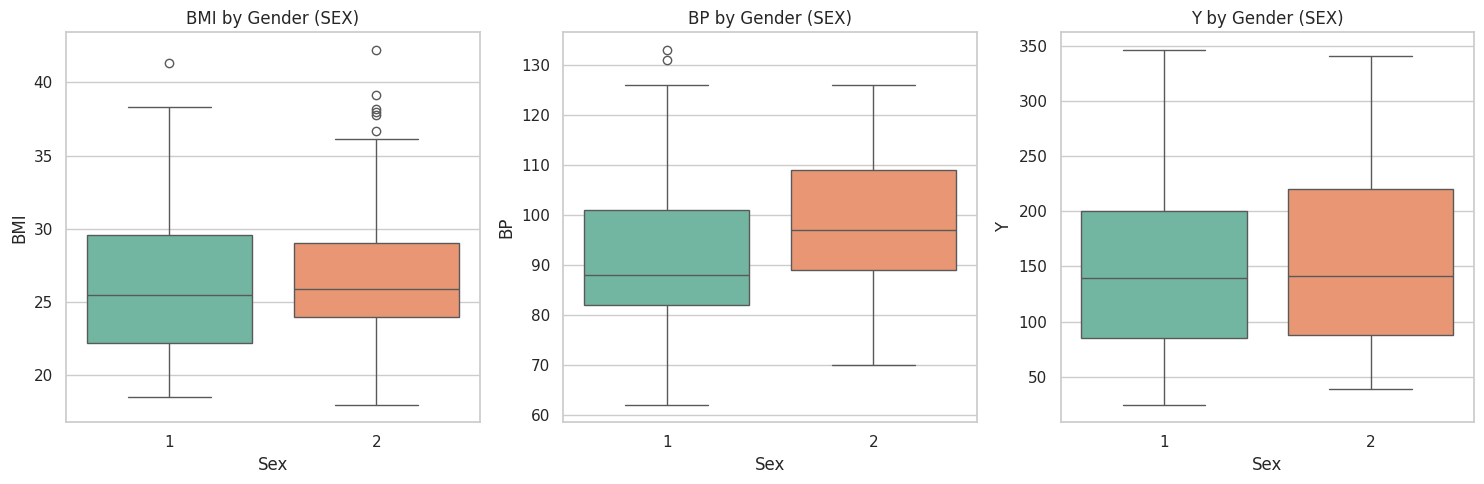

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 从 sample_data 目录读取 diabetes.tsv 文件[cite: 1]
df = pd.read_csv("sample_data/diabetes.tsv", sep='\t')

# 设置图表样式
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 需要绘制的特征列
features = ['BMI', 'BP', 'Y']

# 循环绘制每个变量针对 SEX 的箱线图
for i, col in enumerate(features):
    sns.boxplot(x='SEX', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Gender (SEX)')
    axes[i].set_xlabel('Sex')
    axes[i].set_ylabel(col)

# 调整布局并展示图表
plt.tight_layout()
plt.show()

### Task 3: What is the the distribution of Age, Sex, BMI and Y variables?

### Task 4: Test the correlation between different variables and disease progression (Y)

> **Hint** Correlation matrix would give you the most useful information on which values are dependent.

### Task 5: Test the hypothesis that the degree of diabetes progression is different between men and women